# Machine Learning Capstone — Review 1

## Classification Track (Part A) — Used Car Dataset

**Scope:** Classification Part A — 5 required algorithms.

This notebook covers:
- Dataset loading and audit
- Data cleaning (numeric conversion, missing values, duplicates)
- Feature engineering (`car_age`)
- Creating a classification target (`PriceCategory`) from `AskPrice`
- EDA on the classification target
- Stratified train/test split
- Preprocessing pipeline (encoding + scaling, fit on train only)
- 5 Classification Part-A algorithms: Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM
- Evaluation: Accuracy, weighted Precision/Recall/F1, classification reports, confusion matrices
- Model comparison and conclusion

**Random state:** 42

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classification Part-A algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

In [2]:
df = pd.read_csv("used_car_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9582, 11)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


## 2. Dataset Audit

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Number of rows: 9582
Number of columns: 11

Data Types:


Brand             str
model             str
Year            int64
Age             int64
kmDriven          str
Transmission      str
Owner             str
FuelType          str
PostedDate        str
AdditionInfo      str
AskPrice          str
dtype: object


Missing Values:


Brand            0
model            0
Year             0
Age              0
kmDriven        47
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64


Duplicate Rows: 724

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,9582,39,Maruti Suzuki,2720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,9582,400,City,330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,9582.0,NaN,NaN,NaN,2016.361094,4.087226,1986.0,2014.0,2017.0,2019.0,2024.0
Age,9582.0,NaN,NaN,NaN,7.638906,4.087226,0.0,5.0,7.0,10.0,38.0
kmDriven,9535,1910,"65,000 km",198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,9582,2,Manual,4800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,9582,2,first,4800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FuelType,9582,3,Diesel,3840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PostedDate,9582,12,Nov-24,8693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdditionInfo,9582,7307,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel",26,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning — Numeric Conversion

`kmDriven` and `AskPrice` contain units, commas, and currency symbols, so they are loaded as
strings. Both are cleaned and converted to numeric so they can be used as model features / to
build the classification target.

In [4]:
# Convert kmDriven to numeric
df["kmDriven"] = (
    df["kmDriven"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" km", "", regex=False)
    .str.strip()
)
df["kmDriven"] = pd.to_numeric(df["kmDriven"], errors="coerce")

# Convert AskPrice to numeric
df["AskPrice"] = (
    df["AskPrice"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["AskPrice"] = pd.to_numeric(df["AskPrice"], errors="coerce")

df[["kmDriven", "AskPrice"]].head()

,kmDriven,AskPrice
0,98000.0,195000
1,190000.0,375000
2,77246.0,184999
3,83500.0,565000
4,45000.0,685000


## 4. Handling Missing Values and Duplicates

Rows with a missing `AskPrice` are dropped, since the classification target is derived from it.
Missing `kmDriven` values are filled with the median, since mileage can contain extreme values
and the median is robust to outliers. Exact duplicate rows are also removed.

In [5]:
df = df.dropna(subset=["AskPrice"]).reset_index(drop=True)

median_km = df["kmDriven"].median()
df["kmDriven"] = df["kmDriven"].fillna(median_km)

duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

print("Median kmDriven used for imputation:", median_km)
print("Duplicate rows removed:", duplicate_count)
print("Missing values remaining:\n", df.isnull().sum())
print("\nDataset shape after cleaning:", df.shape)

Median kmDriven used for imputation: 65000.0
Duplicate rows removed: 731
Missing values remaining:
 Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64

Dataset shape after cleaning: (8851, 11)


## 5. Feature Engineering — Car Age

`car_age` is derived from `Year`. Car age is directly relevant to used-car pricing, since older
vehicles generally depreciate. The current year, 2026, is used as the reference year.

In [6]:
df["car_age"] = 2026 - df["Year"]

df[["Year", "car_age"]].head()

,Year,car_age
0,2001,25
1,2009,17
2,2010,16
3,2017,9
4,2019,7


## 6. Creating the Classification Target — `PriceCategory`

The raw dataset does not include a categorical label, and `AskPrice` was used as the regression
target elsewhere in this project. For the classification track, `AskPrice` is binned into three
categories — **Low**, **Medium**, **High** — using quantile-based binning (`pd.qcut`), so each
category has a roughly equal number of listings.

`AskPrice` is dropped from the feature set afterwards, since keeping it would leak the target.

In [7]:
df["PriceCategory"] = pd.qcut(
    df["AskPrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("Class distribution:")
display(df["PriceCategory"].value_counts())

print("\nPrice range per category:")
display(df.groupby("PriceCategory")["AskPrice"].agg(["min", "max", "count"]))

Class distribution:


PriceCategory
Low       2961
High      2950
Medium    2940
Name: count, dtype: int64


Price range per category:


,min,max,count
PriceCategory,,,
Low,15000,425000,2961
Medium,425001,839999,2940
High,840000,42500000,2950


## 7. Target Distribution

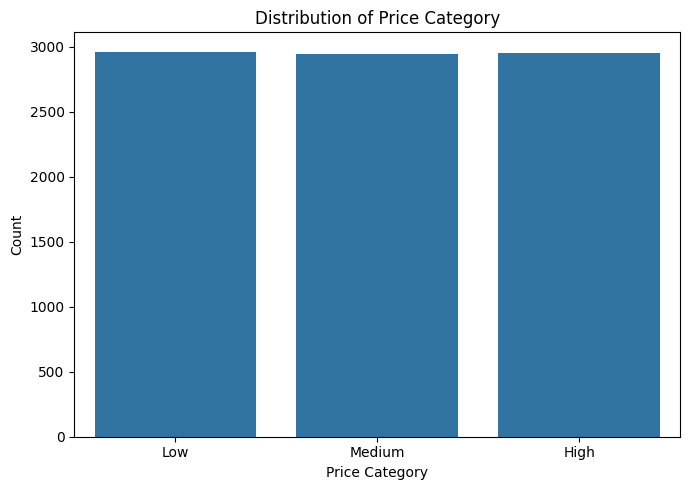

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="PriceCategory",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Price Category")
plt.xlabel("Price Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Observation

The quantile-based binning produces a near-balanced target, with each price category holding
roughly a third of the listings. This avoids the class-imbalance issues that a naturally skewed
label (like `AskPrice` itself) would introduce for the classifiers.

## 8. Feature vs Price Category

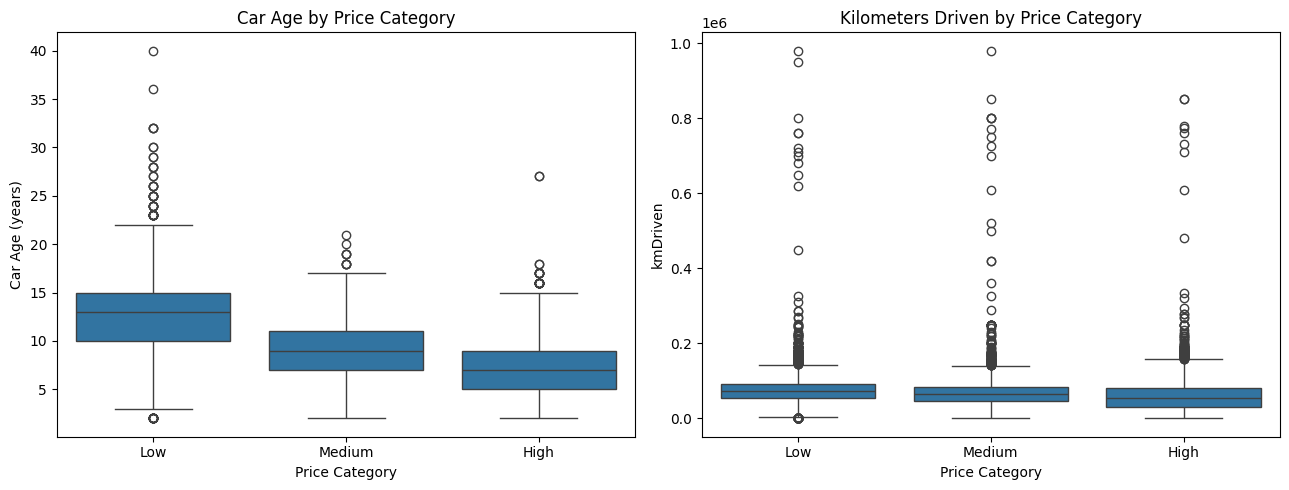

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="PriceCategory", y="car_age", order=["Low", "Medium", "High"], ax=axes[0])
axes[0].set_title("Car Age by Price Category")
axes[0].set_xlabel("Price Category")
axes[0].set_ylabel("Car Age (years)")

sns.boxplot(data=df, x="PriceCategory", y="kmDriven", order=["Low", "Medium", "High"], ax=axes[1])
axes[1].set_title("Kilometers Driven by Price Category")
axes[1].set_xlabel("Price Category")
axes[1].set_ylabel("kmDriven")

plt.tight_layout()
plt.show()

### Observation

Cars in the **Low** price category tend to be older and more heavily driven, while cars in the
**High** category are generally newer with lower mileage. This confirms `car_age` and `kmDriven`
carry useful signal for separating the price categories.

## 9. Feature and Target Selection

The same explanatory features used for the regression track are reused here: brand, model,
mileage, transmission, ownership history, fuel type, and engineered car age. `AskPrice` and
`Year` are excluded, since `AskPrice` directly determines the target and `Year` is redundant
with `car_age`.

In [10]:
features = [
    "Brand",
    "model",
    "kmDriven",
    "Transmission",
    "Owner",
    "FuelType",
    "car_age"
]

X_cls = df[features].copy()
y_cls = df["PriceCategory"].copy()

print("X shape:", X_cls.shape)
print("y shape:", y_cls.shape)

X shape: (8851, 7)
y shape: (8851,)


## 10. Stratified Train/Test Split

In [11]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

print("Training:", X_train_cls.shape)
print("Testing:", X_test_cls.shape)

Training: (7080, 7)
Testing: (1771, 7)


## 11. Preprocessing Pipeline

Categorical features are one-hot encoded and numerical features are standardised. All
transformers are fitted on the training set only and then applied to the test set, to avoid
data leakage.

In [12]:
categorical_cls = X_cls.select_dtypes(include=["object"]).columns.tolist()
numerical_cls = X_cls.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:", categorical_cls)
print("Numerical features:", numerical_cls)

classification_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_cls
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical_cls
        )
    ]
)

Categorical features: ['Brand', 'model', 'Transmission', 'Owner', 'FuelType']
Numerical features: ['kmDriven', 'car_age']


## 12. Define Classification Part-A Models

The five algorithms required for Review 1:
1. Logistic Regression
2. K-Nearest Neighbors
3. Naive Bayes (Gaussian)
4. Decision Tree Classifier
5. Support Vector Machine (SVC)

In [13]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "SVM": SVC(
        kernel="rbf",
        C=1
    )
}

## 13. Train All Classification Part-A Models

In [14]:
classification_results = []
trained_classification_models = {}

for name, model in classification_models.items():

    print(f"Training {name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", classification_preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_cls, y_train_cls)

    predictions = pipeline.predict(X_test_cls)

    accuracy = accuracy_score(y_test_cls, predictions)
    precision = precision_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_classification_models[name] = pipeline

classification_results_df = pd.DataFrame(classification_results)

classification_results_df = (
    classification_results_df
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

display(classification_results_df)

Training Logistic Regression...


Training KNN...


Training Naive Bayes...
Training Decision Tree...


Training SVM...


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.875212,0.876411,0.875212,0.875678
1,SVM,0.871824,0.874137,0.871824,0.872624
2,KNN,0.828910,0.828448,0.828910,0.828660
3,Decision Tree,0.819311,0.818627,0.819311,0.818905
4,Naive Bayes,0.640881,0.787553,0.640881,0.638956


## 14. Classification Reports

In [15]:
for name, model in trained_classification_models.items():

    predictions = model.predict(X_test_cls)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test_cls,
            predictions,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

        High       0.92      0.91      0.91       590
         Low       0.90      0.88      0.89       593
      Medium       0.81      0.84      0.82       588

    accuracy                           0.88      1771
   macro avg       0.88      0.88      0.88      1771
weighted avg       0.88      0.88      0.88      1771



KNN
              precision    recall  f1-score   support

        High       0.88      0.89      0.89       590
         Low       0.84      0.84      0.84       593
      Medium       0.76      0.75      0.76       588

    accuracy                           0.83      1771
   macro avg       0.83      0.83      0.83      1771
weighted avg       0.83      0.83      0.83      1771

Naive Bayes
              precision    recall  f1-score   support

        High       0.96      0.54      0.69       590
         Low       0.91      0.42      0.58       593
      Medium       0.48      0.96      0.64       588

    accuracy                           0.64      1771
   macro avg       0.79      0.64      0.64      1771
weighted avg       0.79      0.64      0.64      1771

Decision Tree
              precision    recall  f1-score   support

        High       0.89      0.89      0.89       590
         Low       0.82      0.84      0.83       593
      Medium       0.75      0.73      0.74  

SVM
              precision    recall  f1-score   support

        High       0.93      0.90      0.91       590
         Low       0.89      0.88      0.88       593
      Medium       0.80      0.84      0.82       588

    accuracy                           0.87      1771
   macro avg       0.87      0.87      0.87      1771
weighted avg       0.87      0.87      0.87      1771



## 15. Confusion Matrices

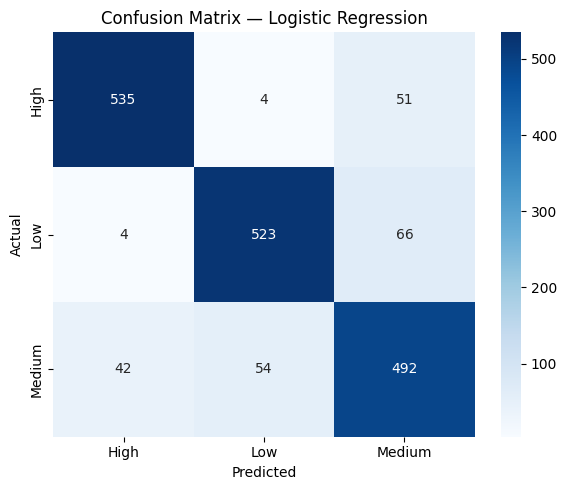

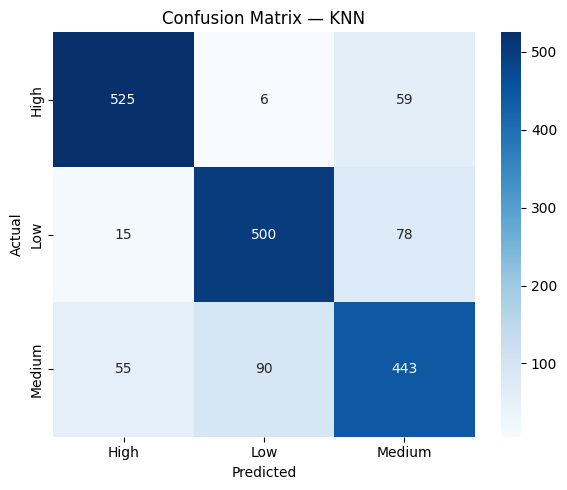

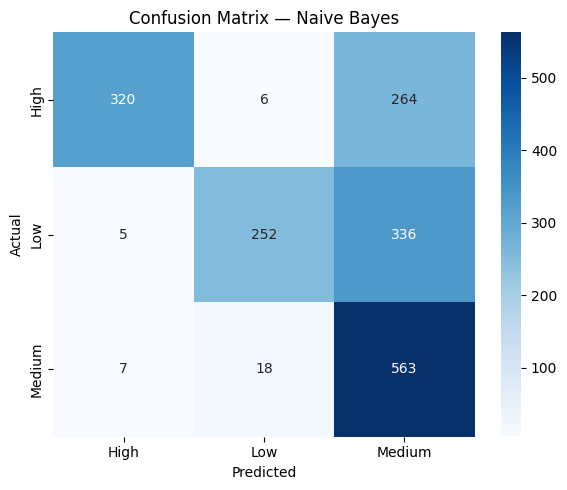

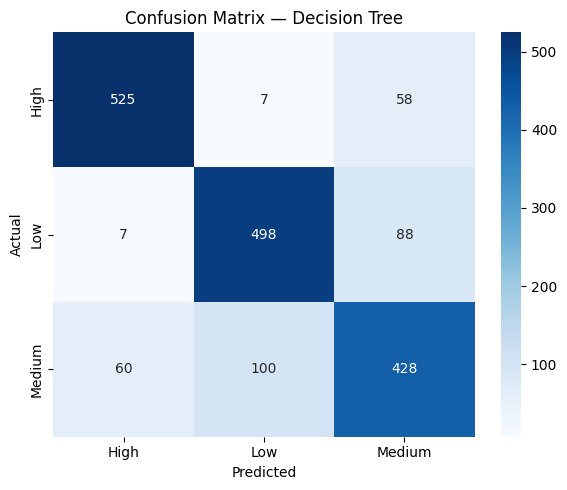

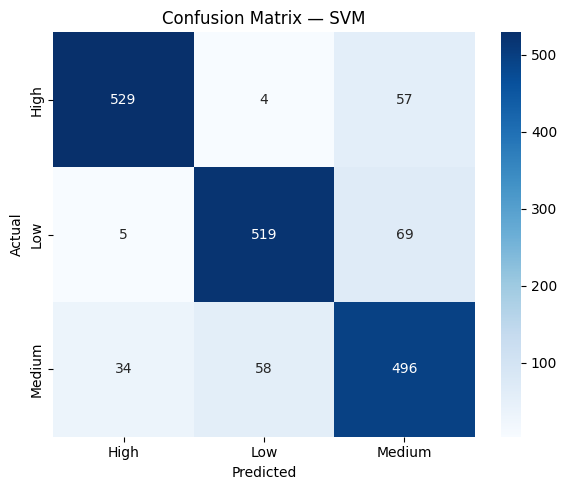

In [16]:
for name, model in trained_classification_models.items():

    predictions = model.predict(X_test_cls)

    cm = confusion_matrix(
        y_test_cls,
        predictions,
        labels=model.classes_
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=model.classes_,
        yticklabels=model.classes_
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 16. Model Comparison

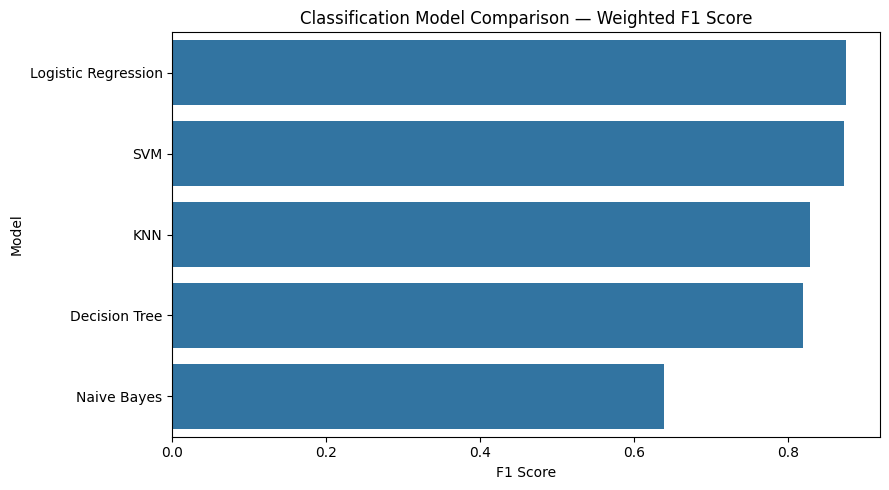

Final Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.875212,0.876411,0.875212,0.875678
1,SVM,0.871824,0.874137,0.871824,0.872624
2,KNN,0.828910,0.828448,0.828910,0.828660
3,Decision Tree,0.819311,0.818627,0.819311,0.818905
4,Naive Bayes,0.640881,0.787553,0.640881,0.638956


In [17]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=classification_results_df,
    x="F1 Score",
    y="Model"
)

plt.title("Classification Model Comparison — Weighted F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

print("Final Comparison Table:")
display(classification_results_df)

# Conclusion

`AskPrice` was binned into three quantile-based classes — Low, Medium, High — to create a
classification target for the used-car dataset, since the raw data only had a continuous price
column. The five Review 1 Part-A classifiers were trained on the same stratified 80:20 split and
the same preprocessing pipeline (median/most-frequent imputation, standard scaling, one-hot
encoding), so their scores are directly comparable.

Logistic Regression came out on top (F1 ≈ 0.876), closely followed by SVM (F1 ≈ 0.873). Both
benefit from the one-hot encoded, scaled feature space being roughly linearly separable across
the three price bands once brand and model are encoded. KNN and Decision Tree trailed a bit
behind (F1 ≈ 0.82-0.83), likely more sensitive to the high dimensionality introduced by one-hot
encoding many brand/model categories. Naive Bayes was clearly the weakest (F1 ≈ 0.64), which
fits its core assumption of conditional independence between features — `car_age`, `kmDriven`,
brand, and fuel type are all correlated with each other in reality, and Naive Bayes can't model
those interactions.

The confusion matrices show most misclassifications happening between adjacent classes
(Low↔Medium, Medium↔High) rather than between the extremes, which makes sense since boundary
listings near the quantile cutoffs are genuinely close in price.

For Review 2, this same target and pipeline can be extended with the remaining five Part-B
algorithms (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) to build the full
10-algorithm comparison table.